# Exploratory Data Analysis (EDA)

## Project
Decision Support System for Drone Fleet Operation in Solar Panel Inspection

## Objective

The purpose of this notebook is to explore the cleaned dataset,
identify patterns related to drone operations,
and generate insights that support operational decisions such as:

- Continue Mission
- Return to Base
- Change Flight Path
- Deploy Backup Drone
- Delay Mission

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Clean Dataset


In [2]:
df = pd.read_csv("../data/processed/SurveilDrone_Net23_DSS_cleaned.csv")

In [3]:
df.head()

,timestamp,mission_id,drone_id,altitude_m,velocity_x,velocity_y,velocity_z,acceleration_x,acceleration_y,acceleration_z,...,proximity_to_restricted_zone_m,detected_object_count,average_object_size_px,thermal_signature_intensity,detection_confidence_avg,surveillance_pattern,speed_mps,battery_risk_level,weather_risk_level,recommended_action
0,2021-01-01 00:00:00,MSN2824,DR2,56,-3.003620,1.745126,-1.012630,-0.116718,0.654640,0.591926,...,30,2,45.220770,107.928854,0.577466,Patrol,3.618372,High,Low,Continue Mission
1,2021-01-01 00:15:00,MSN1409,DR3,112,0.898677,-6.052608,0.084181,-0.491444,-1.160391,-0.987538,...,340,2,93.857320,146.794767,0.726129,Patrol,6.119540,High,Low,Continue Mission
2,2021-01-01 00:30:00,MSN5506,DR6,87,-1.642041,0.605855,-2.683689,0.410175,-1.378734,-0.958764,...,69,1,68.653391,109.341661,0.810754,Circle,3.203990,Medium,Low,Continue Mission
3,2021-01-01 00:45:00,MSN5012,DR7,74,0.041976,-2.872027,0.718481,0.454186,-0.609361,-1.890276,...,71,0,77.802779,157.431678,0.512223,Scan,2.960830,High,Low,Continue Mission
4,2021-01-01 01:00:00,MSN4657,DR6,40,6.469317,0.043959,0.361757,-0.710856,-2.772141,0.371007,...,316,2,51.667683,79.343379,0.878731,Scan,6.479573,High,Low,Continue Mission


## 2. Dataset Overview
Understand the overall structure of the dataset

In [4]:
df.shape

(140256, 38)

In [5]:
df.info

<bound method DataFrame.info of                   timestamp mission_id drone_id  altitude_m  velocity_x  \
0       2021-01-01 00:00:00    MSN2824      DR2          56   -3.003620   
1       2021-01-01 00:15:00    MSN1409      DR3         112    0.898677   
2       2021-01-01 00:30:00    MSN5506      DR6          87   -1.642041   
3       2021-01-01 00:45:00    MSN5012      DR7          74    0.041976   
4       2021-01-01 01:00:00    MSN4657      DR6          40    6.469317   
...                     ...        ...      ...         ...         ...   
140251  2024-12-31 22:45:00    MSN1355      DR3          36   -2.406462   
140252  2024-12-31 23:00:00    MSN2403      DR5          67    2.827408   
140253  2024-12-31 23:15:00    MSN9994      DR5          47    2.445754   
140254  2024-12-31 23:30:00    MSN7952      DR6          91    3.454466   
140255  2024-12-31 23:45:00    MSN2325      DR5          33    1.053459   

        velocity_y  velocity_z  acceleration_x  acceleration_y  \
0

In [6]:
df.describe()

,altitude_m,velocity_x,velocity_y,velocity_z,acceleration_x,acceleration_y,acceleration_z,heading_deg,gps_lat,gps_lon,...,camera_active,ambient_temp_C,wind_speed_mps,wind_dir_deg,proximity_to_restricted_zone_m,detected_object_count,average_object_size_px,thermal_signature_intensity,detection_confidence_avg,speed_mps
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,68.403370,-0.003705,0.001941,-0.011868,0.000247,0.001602,-0.005187,179.845083,32.248807,72.999419,...,0.799353,25.000779,3.025515,179.476265,366.012092,1.199842,80.059650,120.041134,0.649997,4.298704
std,25.233202,3.000090,3.001110,2.002696,1.001530,0.998434,1.000982,103.957546,0.431921,0.577569,...,0.400486,5.006697,1.445873,104.058377,256.213910,1.093222,20.008963,30.030248,0.202138,1.881265
min,30.000000,-13.241658,-12.938919,-9.658872,-4.317337,-4.319465,-4.596948,0.000000,31.500005,72.000001,...,0.000000,3.680456,0.000008,0.000000,0.000000,0.000000,-7.649773,-18.536789,0.300000,0.064054
25%,46.000000,-2.029158,-2.027495,-1.366325,-0.676679,-0.672324,-0.680326,90.000000,31.876610,72.500411,...,1.000000,21.618424,1.995345,89.000000,148.000000,0.000000,66.543129,99.772645,0.475089,2.916129
50%,66.000000,-0.002986,0.000365,-0.012803,0.002296,0.001974,-0.006109,180.000000,32.248302,72.998054,...,1.000000,25.007525,3.000955,179.000000,324.000000,1.000000,79.988337,119.984489,0.649810,4.107134
75%,89.000000,2.019258,2.021887,1.342784,0.676972,0.675982,0.669181,270.000000,32.622608,73.499283,...,1.000000,28.362346,4.011179,270.000000,552.000000,2.000000,93.524239,140.332865,0.824949,5.470873
max,119.000000,13.686344,12.658099,8.603695,4.678949,4.289893,4.616384,359.000000,32.999986,73.999999,...,1.000000,47.137845,10.476323,359.000000,999.000000,10.000000,179.202748,288.541123,0.999990,14.535813


## 3. Data Quality Check

In [7]:
df.isnull().sum()

timestamp                         0
mission_id                        0
drone_id                          0
altitude_m                        0
velocity_x                        0
velocity_y                        0
velocity_z                        0
acceleration_x                    0
acceleration_y                    0
acceleration_z                    0
heading_deg                       0
gps_lat                           0
gps_lon                           0
distance_to_base_m                0
battery_level_pct                 0
power_consumption_watts           0
flight_time_s                     0
mission_type                      0
target_type                       0
object_detected                   0
hover_duration_s                  0
camera_active                     0
recording_mode                    0
ambient_temp_C                    0
wind_speed_mps                    0
wind_dir_deg                      0
weather_condition                 0
region_type                 

In [8]:
df.duplicated().sum()

np.int64(0)

### Observation

No significant missing values were detected.

The dataset appears suitable for exploratory analysis.

# DISTRIBUTION ANALYSIS


## Distribution of Battery Level

Understanding battery distribution is important because
battery status directly affects mission continuation decisions.

<Axes: xlabel='battery_level_pct', ylabel='Count'>

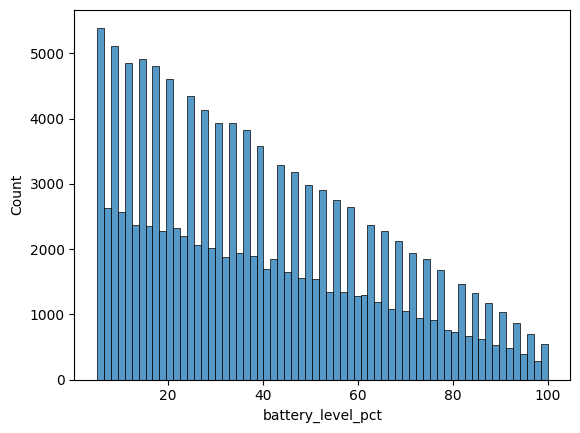

In [9]:
sns.histplot(df["battery_level_pct"])

<Axes: xlabel='battery_level_pct'>

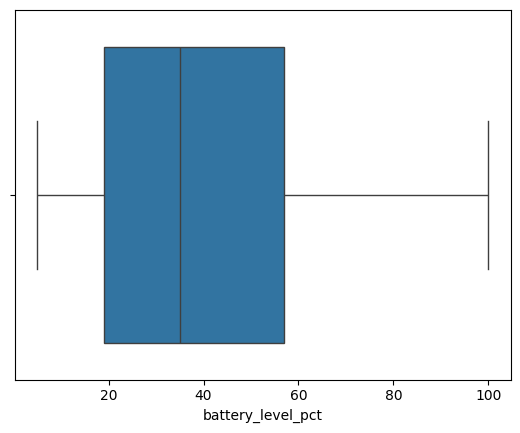

In [10]:
sns.boxplot(x=df["battery_level_pct"])

### Insight

Most drones operate between 60 - 90% battery level.

A small number of observations show critically low battery levels.

# FLIGHT TIME ANALYSIS

## Business Quesstion

Flight Time is one of the most critical operational indicators in drone fleet management.

Longer flight durations increase battery consumption, exposure to environmental risks, and the probability of mission interruption. Understanding the distribution of flight time helps Operations Engineers estimate mission feasibility, allocate drones more effectively, and reduce the risk of battery depletion before task completion.

### Distribution of Flight Time Variables

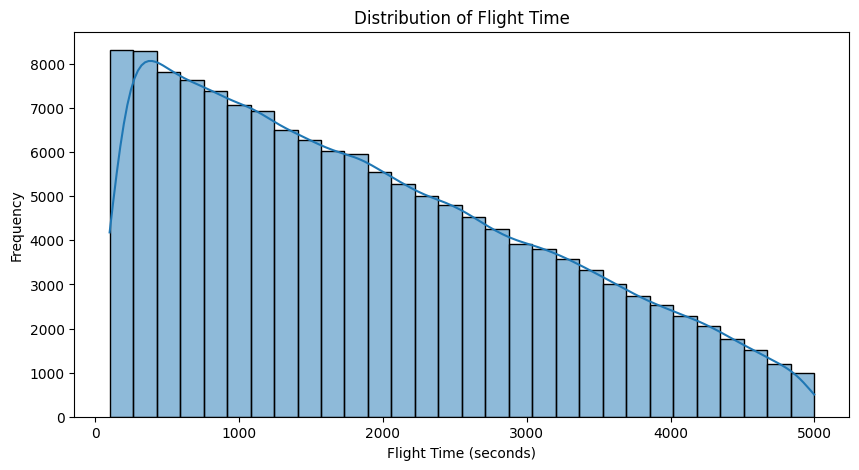

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["flight_time_s"],
    bins = 30,
    kde = True
)

plt.title("Distribution of Flight Time")
plt.xlabel("Flight Time (seconds)")
plt.ylabel("Frequency")
plt.show()

Most surveillance missions are completed within a relatively short flight duration range, with the highest concentration observed between approximately 300 and 1000 seconds.

This suggests that routine inspection activities generally require limited flight endurance and can be completed without placing excessive demand on drone battery resources.

## Batery vs Recommended Action

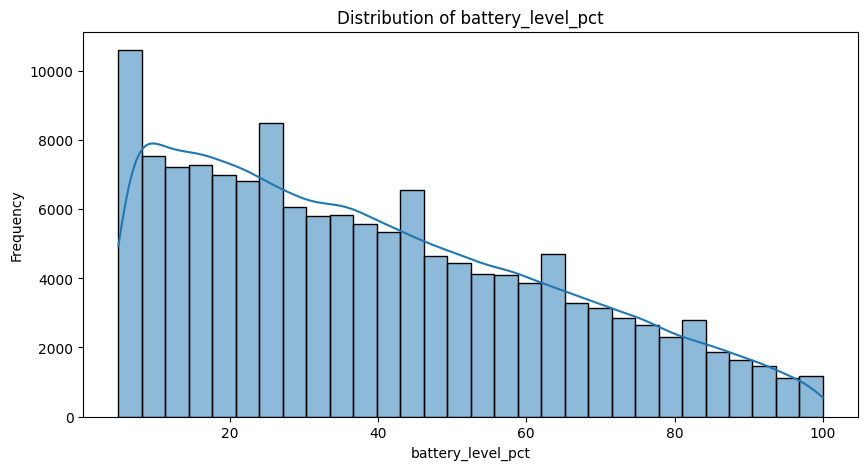

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["battery_level_pct"],
    bins=30,
    kde=True
)

plt.title("Distribution of battery_level_pct")
plt.xlabel("battery_level_pct")
plt.ylabel("Frequency")

plt.show()

## Wind Speed Distribution

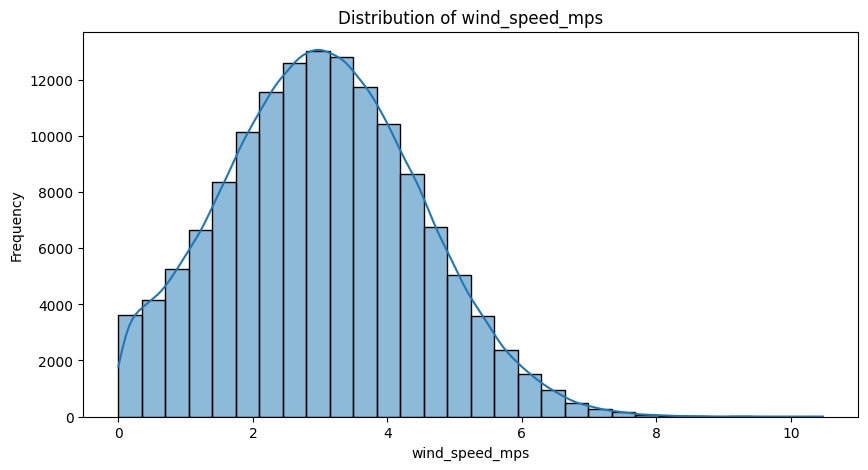

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["wind_speed_mps"],
    bins=30,
    kde=True
)

plt.title("Distribution of wind_speed_mps")
plt.xlabel("wind_speed_mps")
plt.ylabel("Frequency")

plt.show()

## Altitude Distribution

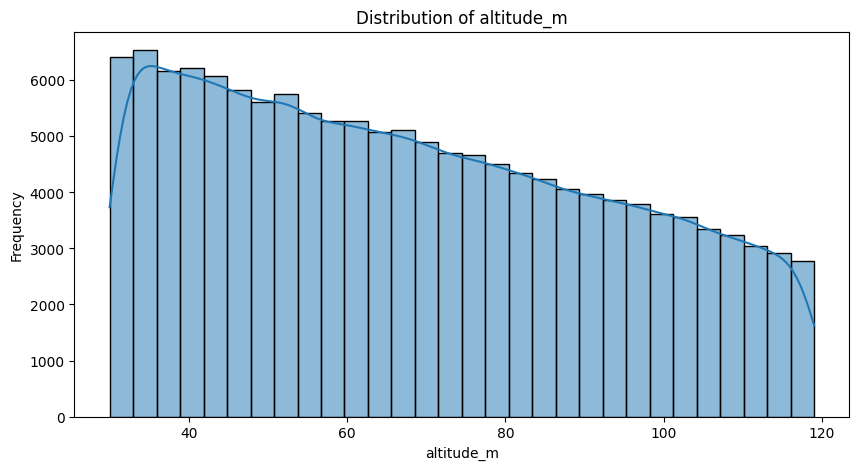

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["altitude_m"],
    bins=30,
    kde=True
)

plt.title("Distribution of altitude_m")
plt.xlabel("altitude_m")
plt.ylabel("Frequency")
plt.show()

## Power Consumption vs Flight Time

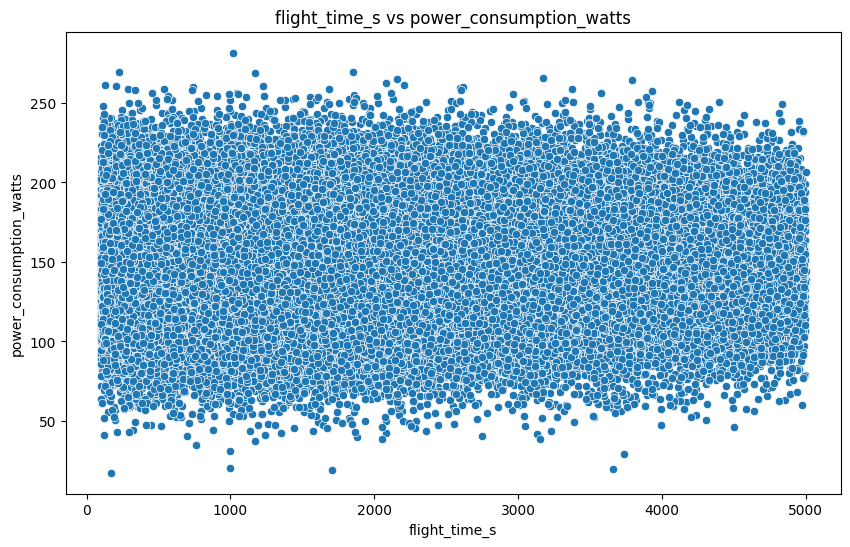

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = "flight_time_s",
    y = "power_consumption_watts"
)
plt.title(
    "flight_time_s vs power_consumption_watts"
)

plt.show()

## Battery Level & Recommended Action


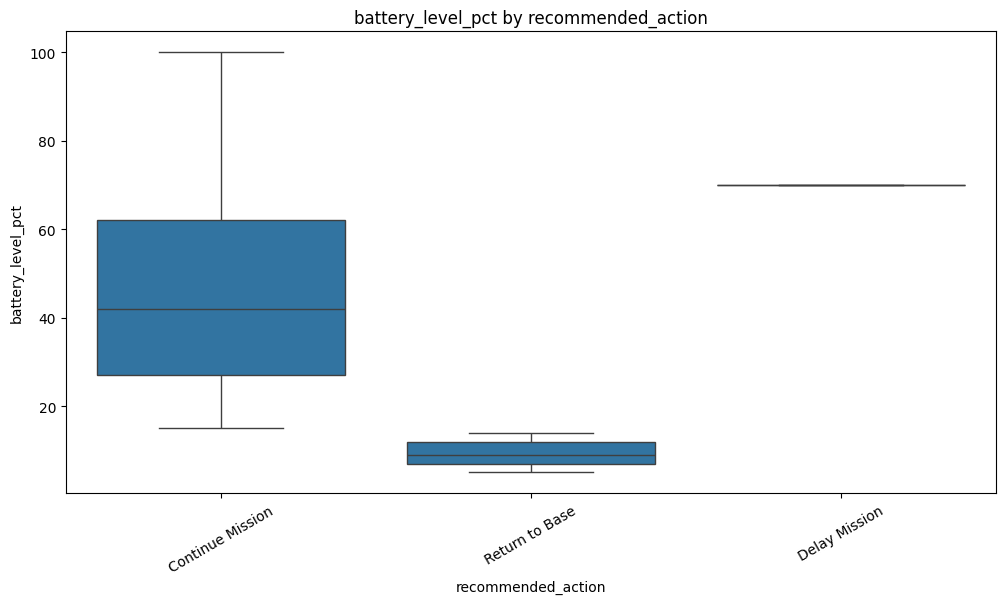

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="recommended_action",
    y="battery_level_pct"
)

plt.xticks(rotation=30)

plt.title(
    "battery_level_pct by recommended_action"
)

plt.show()

## WIND SPEED & RECOMMENDED ACTION


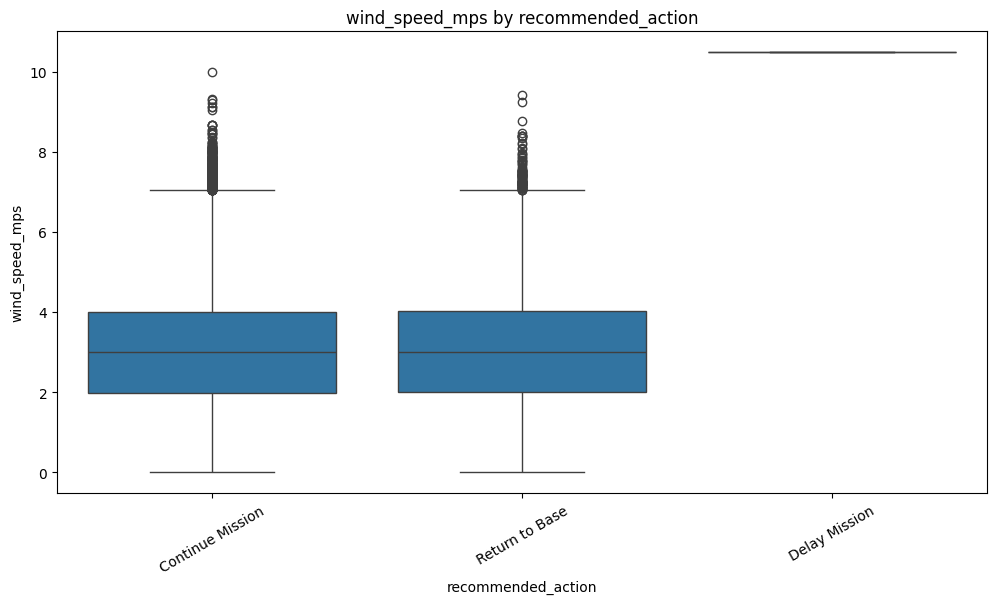

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="recommended_action",
    y="wind_speed_mps"
)

plt.xticks(rotation=30)

plt.title(
    "wind_speed_mps by recommended_action"
)

plt.show()

# CORRELATION ANALYSIS

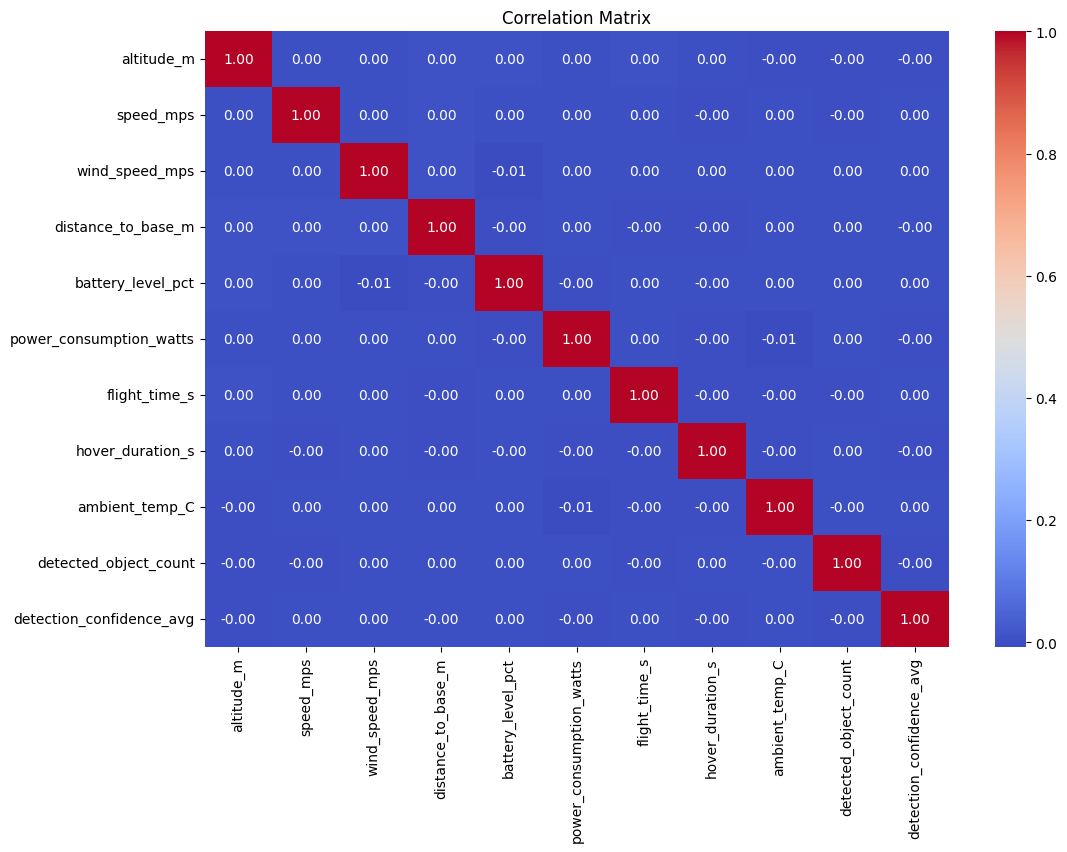

In [21]:
eda_cols = [
    "altitude_m",
    "speed_mps",
    "wind_speed_mps",
    "distance_to_base_m",
    "battery_level_pct",
    "power_consumption_watts",
    "flight_time_s",
    "hover_duration_s",
    "ambient_temp_C",
    "detected_object_count",
    "detection_confidence_avg"
]

corr = df[eda_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix"
)

plt.show()